# COM748 – Predicting 30-Day Hospital Readmission in Diabetic Patients
**Student:** Adewunmi Tobi Evans (B01056179) · **Module:** COM748 Masters Research Project, Ulster University

Compares **Logistic Regression**, **Random Forest** and **XGBoost** on the UCI *Diabetes 130-US Hospitals (1999-2008)* dataset, with SHAP for interpretability.

**How to run:** put `diabetic_data.csv` in the same folder as this notebook (in Google Colab you will be asked to upload it), then run the cells from top to bottom. All random seeds are fixed (`random_state=1`).

**Data source:** UCI Machine Learning Repository, *Diabetes 130-US hospitals for years 1999-2008*. `IDS_mapping.csv` (from the same download) was used only as a reference to interpret the admission/discharge codes; the code does not load it.

## 1. Setup and reproducibility

In [ ]:
!pip install xgboost shap imbalanced-learn --quiet

In [ ]:
import random
import numpy as np

def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)

set_seed(1)
print("Seed set — reproducibility locked in.")

Seed set — reproducibility locked in.


## 2. Data loading and cleaning

In [ ]:
import os
import pandas as pd

# Load the dataset (in Google Colab, upload diabetic_data.csv when prompted)
if not os.path.exists("diabetic_data.csv"):
    from google.colab import files
    files.upload()

df = pd.read_csv("diabetic_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# How many missing values per column (showing only columns that have any)
missing = df.isnull().sum()
print("Missing values (standard blanks):")
print(missing[missing > 0])

print("\n--- Data types ---")
print(df.dtypes.value_counts())

print("\n--- Columns using '?' as missing instead of blank ---")
for col in df.columns:
    if df[col].astype(str).str.contains(r'\?').any():
        count = (df[col].astype(str) == '?').sum()
        print(f"{col}: {count} missing ('?')")

Missing values (standard blanks):
max_glu_serum    96420
A1Cresult        84748
dtype: int64

--- Data types ---
object    37
int64     13
Name: count, dtype: int64

--- Columns using '?' as missing instead of blank ---
race: 2273 missing ('?')
weight: 98569 missing ('?')
payer_code: 40256 missing ('?')
medical_specialty: 49949 missing ('?')
diag_1: 21 missing ('?')
diag_2: 358 missing ('?')
diag_3: 1423 missing ('?')


In [ ]:
# Drop columns that are too sparse or not relevant
df = df.drop(columns=['weight', 'payer_code'])

# For lab tests, missing = "not tested", which is meaningful — keep it as a category
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not tested')

# Fill other missing categorical values sensibly
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')
df['race'] = df['race'].replace('?', 'Unknown')
df['diag_2'] = df['diag_2'].replace('?', 'None')
df['diag_3'] = df['diag_3'].replace('?', 'None')

# Drop the 21 rows missing diag_1 (too few to matter)
df = df[df['diag_1'] != '?']

print("New shape:", df.shape)
print("\nRemaining missing values check:")
print((df == '?').sum().sum(), "question marks left in the data")

New shape: (101745, 48)

Remaining missing values check:
0 question marks left in the data


In [ ]:
# Codes 11, 13, 14, 19, 20, 21 all relate to death or hospice discharge
expired_codes = [11, 13, 14, 19, 20, 21]

before = df.shape[0]
df = df[~df['discharge_disposition_id'].isin(expired_codes)]
after = df.shape[0]

print(f"Removed {before - after} rows (deceased/hospice patients)")
print("New shape:", df.shape)

Removed 2422 rows (deceased/hospice patients)
New shape: (99323, 48)


In [ ]:
# Turn the 3-category column into a simple 1/0 target
# 1 = readmitted within 30 days, 0 = everything else
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted_30d'].value_counts())
print("\nPercentage readmitted within 30 days:", round(df['readmitted_30d'].mean() * 100, 2), "%")

readmitted_30d
0    88014
1    11309
Name: count, dtype: int64

Percentage readmitted within 30 days: 11.39 %


## 3. Feature engineering

In [ ]:
# Combine prior visit counts into one overall "prior utilization" feature
df['total_prior_visits'] = (
    df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
)

print(df['total_prior_visits'].describe())

count    99323.000000
mean         1.198605
std          2.294361
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         80.000000
Name: total_prior_visits, dtype: float64


In [ ]:
def categorize_diagnosis(code):
    try:
        code = float(code)
    except:
        return 'Other'  # handles codes like 'V12' or 'E codes' that aren't plain numbers

    if 390 <= code <= 459 or code == 785:
        return 'Circulatory'
    elif 460 <= code <= 519 or code == 786:
        return 'Respiratory'
    elif 520 <= code <= 579 or code == 787:
        return 'Digestive'
    elif 250 <= code < 251:
        return 'Diabetes'
    elif 800 <= code <= 999:
        return 'Injury'
    elif 710 <= code <= 739:
        return 'Musculoskeletal'
    elif 580 <= code <= 629 or code == 788:
        return 'Genitourinary'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

df['diag_1_category'] = df['diag_1'].apply(categorize_diagnosis)

print(df['diag_1_category'].value_counts())

diag_1_category
Circulatory        29681
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Name: count, dtype: int64


In [ ]:
med_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Count how many of these 23 columns show a change (Up or Down) for each patient
df['num_meds_changed'] = (df[med_columns] == 'Up').sum(axis=1) + (df[med_columns] == 'Down').sum(axis=1)

print(df['num_meds_changed'].describe())

count    99323.000000
mean         0.287396
std          0.487880
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: num_meds_changed, dtype: float64


In [ ]:
# Drop columns we no longer need:
# - IDs aren't predictive features
# - raw diagnosis/medication/visit columns are now summarized by our new features
# - original 'readmitted' is replaced by our clean 'readmitted_30d' target
drop_cols = ['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3',
             'number_outpatient', 'number_emergency', 'number_inpatient',
             'readmitted'] + med_columns

df_model = df.drop(columns=drop_cols)

# Convert remaining text/category columns into numeric 0/1 columns
df_model = pd.get_dummies(df_model, drop_first=True)

print("Final model-ready shape:", df_model.shape)
print("\nTarget balance check:")
print(df_model['readmitted_30d'].value_counts())

Final model-ready shape: (99323, 115)

Target balance check:
readmitted_30d
0    88014
1    11309
Name: count, dtype: int64


## 4. Train/test split and column-name clean-up
Stratified 80/20 split. Column names are cleaned afterwards because XGBoost does not accept `[`, `]` or `<` in feature names.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['readmitted_30d'])
y = df_model['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining set readmission rate:", round(y_train.mean() * 100, 2), "%")
print("Test set readmission rate:", round(y_test.mean() * 100, 2), "%")

Training set shape: (79458, 114)
Test set shape: (19865, 114)

Training set readmission rate: 11.39 %
Test set readmission rate: 11.39 %


In [ ]:
import re

# Clean up column names so XGBoost accepts them
X_train.columns = [re.sub(r'[\[\]<]', '', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '', col) for col in X_test.columns]

print("Column names cleaned.")
print(X_train.columns[:10].tolist())

Column names cleaned.
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'total_prior_visits', 'num_meds_changed']


## 5. Baseline models
### 5.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic regression is sensitive to feature scale, so we standardize first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     17603
           1       0.17      0.53      0.25      2262

    accuracy                           0.65     19865
   macro avg       0.54      0.60      0.51     19865
weighted avg       0.83      0.65      0.71     19865

AUC-ROC: 0.6394


### 5.2 Random Forest
With the default 0.5 cut-off the Random Forest almost never predicts a readmission (recall ≈ 0), so we examine the decision threshold.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"AUC-ROC: {auc_rf:.4f}")
print(f"\nFor comparison — Logistic Regression AUC-ROC was: 0.6394")

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17603
           1       0.35      0.00      0.01      2262

    accuracy                           0.89     19865
   macro avg       0.62      0.50      0.47     19865
weighted avg       0.82      0.89      0.83     19865

AUC-ROC: 0.6407

For comparison — Logistic Regression AUC-ROC was: 0.6394


In [ ]:
# Try a lower threshold — e.g. flag anyone with >20% predicted risk, not just >50%
threshold = 0.2
y_pred_rf_adjusted = (y_pred_proba_rf >= threshold).astype(int)

print(f"Classification Report (Random Forest, threshold = {threshold}):")
print(classification_report(y_test, y_pred_rf_adjusted))

Classification Report (Random Forest, threshold = 0.2):
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     17603
           1       0.23      0.21      0.22      2262

    accuracy                           0.83     19865
   macro avg       0.57      0.56      0.56     19865
weighted avg       0.82      0.83      0.83     19865



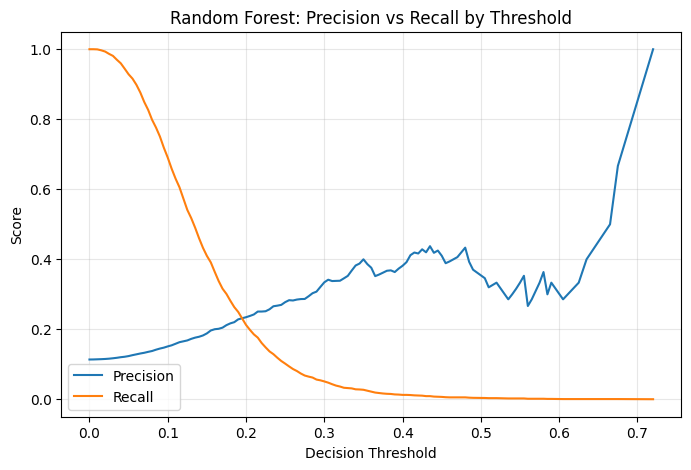

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Random Forest: Precision vs Recall by Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rf_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold — Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

y_pred_rf_best = (y_pred_proba_rf >= best_threshold).astype(int)
print("\nFull Classification Report at best threshold:")
print(classification_report(y_test, y_pred_rf_best))

Best threshold: 0.155
At this threshold — Precision: 0.197, Recall: 0.391, F1: 0.262

Full Classification Report at best threshold:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     17603
           1       0.20      0.39      0.26      2262

    accuracy                           0.75     19865
   macro avg       0.55      0.59      0.56     19865
weighted avg       0.83      0.75      0.78     19865



### 5.3 XGBoost

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance for XGBoost specifically —
# it's roughly (number of negative cases / number of positive cases)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=1
)
xgb.fit(X_train, y_train)

print("XGBoost trained successfully.")
print(f"scale_pos_weight used: {scale_weight:.2f}")

XGBoost trained successfully.
scale_pos_weight used: 7.78


In [ ]:
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost AUC-ROC: {auc_xgb:.4f}")

print(f"\nFor comparison:")
print(f"Logistic Regression AUC-ROC: 0.6394")
print(f"Random Forest AUC-ROC:       0.6407")
print(f"XGBoost AUC-ROC:             {auc_xgb:.4f}")

XGBoost AUC-ROC: 0.6264

For comparison:
Logistic Regression AUC-ROC: 0.6394
Random Forest AUC-ROC:       0.6407
XGBoost AUC-ROC:             0.6264


## 6. Hyperparameter tuning (RandomizedSearchCV, 3-fold, scoring = ROC-AUC)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=1,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("Best parameters found:", xgb_search.best_params_)
print("Best cross-validated AUC-ROC:", round(xgb_search.best_score_, 4))

xgb_tuned = xgb_search.best_estimator_

Best parameters found: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best cross-validated AUC-ROC: 0.6549


In [ ]:
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned)
print(f"Tuned XGBoost AUC-ROC (on held-out test set): {auc_xgb_tuned:.4f}")

print(f"\nFinal comparison so far:")
print(f"Logistic Regression:     0.6394")
print(f"Random Forest:           0.6407")
print(f"XGBoost (untuned):       0.6264")
print(f"XGBoost (tuned):         {auc_xgb_tuned:.4f}")

Tuned XGBoost AUC-ROC (on held-out test set): 0.6646

Final comparison so far:
Logistic Regression:     0.6394
Random Forest:           0.6407
XGBoost (untuned):       0.6264
XGBoost (tuned):         0.6646


In [ ]:
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=1, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=1,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best parameters found:", rf_search.best_params_)
print("Best cross-validated AUC-ROC:", round(rf_search.best_score_, 4))

rf_tuned = rf_search.best_estimator_

# Evaluate on the real test set
y_pred_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)
print(f"\nTuned Random Forest AUC-ROC (test set): {auc_rf_tuned:.4f}")

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
Best cross-validated AUC-ROC: 0.649

Tuned Random Forest AUC-ROC (test set): 0.6573


In [ ]:
param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
}

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear', random_state=1),
    param_distributions=param_dist_lr,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=1,
    n_jobs=-1
)
lr_search.fit(X_train_scaled, y_train)

print("Best parameters found:", lr_search.best_params_)
print("Best cross-validated AUC-ROC:", round(lr_search.best_score_, 4))

lr_tuned = lr_search.best_estimator_

y_pred_proba_lr_tuned = lr_tuned.predict_proba(X_test_scaled)[:, 1]
auc_lr_tuned = roc_auc_score(y_test, y_pred_proba_lr_tuned)
print(f"\nTuned Logistic Regression AUC-ROC (test set): {auc_lr_tuned:.4f}")

Best parameters found: {'penalty': 'l1', 'C': 0.01}
Best cross-validated AUC-ROC: 0.639

Tuned Logistic Regression AUC-ROC (test set): 0.6409


## 7. Statistical evaluation
### 7.1 Bootstrap 95% confidence intervals for AUC-ROC (tuned models)

In [ ]:
import numpy as np

def bootstrap_auc(y_true, y_proba, n_bootstraps=1000, seed=1):
    rng = np.random.RandomState(seed)
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    scores = []
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue  # skip resamples that accidentally have only one class
        score = roc_auc_score(y_true[indices], y_proba[indices])
        scores.append(score)
    return np.array(scores)

# Get probability predictions from our three TUNED models
y_proba_lr = lr_tuned.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

boot_lr = bootstrap_auc(y_test, y_proba_lr)
boot_rf = bootstrap_auc(y_test, y_proba_rf)
boot_xgb = bootstrap_auc(y_test, y_proba_xgb)

for name, scores in [('Logistic Regression', boot_lr), ('Random Forest', boot_rf), ('XGBoost', boot_xgb)]:
    lower, upper = np.percentile(scores, [2.5, 97.5])
    print(f"{name}: mean AUC = {scores.mean():.4f}, 95% CI = [{lower:.4f}, {upper:.4f}]")

Logistic Regression: mean AUC = 0.6407, 95% CI = [0.6294, 0.6528]
Random Forest: mean AUC = 0.6572, 95% CI = [0.6463, 0.6687]
XGBoost: mean AUC = 0.6645, 95% CI = [0.6525, 0.6766]


### 7.2 DeLong's test (paired comparison of ROC curves)

In [ ]:
def delong_roc_test(y_true, proba_1, proba_2):
    """Compare two ROC-AUC scores using DeLong's test. Returns z-statistic and p-value."""
    from scipy.stats import norm

    def compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(N)
        T2[J] = T
        return T2

    y_true = np.array(y_true)
    order = np.argsort(-y_true)
    y_true = y_true[order]
    proba_1 = np.array(proba_1)[order]
    proba_2 = np.array(proba_2)[order]

    m = int(np.sum(y_true))  # positives
    n = len(y_true) - m      # negatives

    predictions = np.vstack((proba_1, proba_2))
    k = predictions.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = compute_midrank(predictions[r, :m])
        ty[r, :] = compute_midrank(predictions[r, m:])
        tz[r, :] = compute_midrank(predictions[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n

    l = np.array([1, -1])
    z = np.abs(np.dot(l, aucs)) / np.sqrt(np.dot(l, np.dot(delongcov, l)))
    p = 2 * (1 - norm.cdf(z))
    return aucs, z, p

print("DeLong's test function ready.")

DeLong's test function ready.


In [ ]:
print("XGBoost vs Random Forest:")
aucs, z, p = delong_roc_test(y_test, y_proba_xgb, y_proba_rf)
print(f"  AUCs: XGBoost={aucs[0]:.4f}, Random Forest={aucs[1]:.4f}")
print(f"  z-statistic: {z:.4f}, p-value: {p:.4f}")

print("\nXGBoost vs Logistic Regression:")
aucs, z, p = delong_roc_test(y_test, y_proba_xgb, y_proba_lr)
print(f"  AUCs: XGBoost={aucs[0]:.4f}, Logistic Regression={aucs[1]:.4f}")
print(f"  z-statistic: {z:.4f}, p-value: {p:.4f}")

print("\nRandom Forest vs Logistic Regression:")
aucs, z, p = delong_roc_test(y_test, y_proba_rf, y_proba_lr)
print(f"  AUCs: Random Forest={aucs[0]:.4f}, Logistic Regression={aucs[1]:.4f}")
print(f"  z-statistic: {z:.4f}, p-value: {p:.4f}")

XGBoost vs Random Forest:
  AUCs: XGBoost=0.6646, Random Forest=0.6573
  z-statistic: 2.1232, p-value: 0.0337

XGBoost vs Logistic Regression:
  AUCs: XGBoost=0.6646, Logistic Regression=0.6409
  z-statistic: 6.4787, p-value: 0.0000

Random Forest vs Logistic Regression:
  AUCs: Random Forest=0.6573, Logistic Regression=0.6409
  z-statistic: 3.9614, p-value: 0.0001


## 8. Interpretability with SHAP (tuned XGBoost)

In [ ]:
import shap

# TreeExplainer is a fast, exact method built specifically for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed.")
print("Shape:", shap_values.shape)

SHAP values computed.
Shape: (19865, 114)


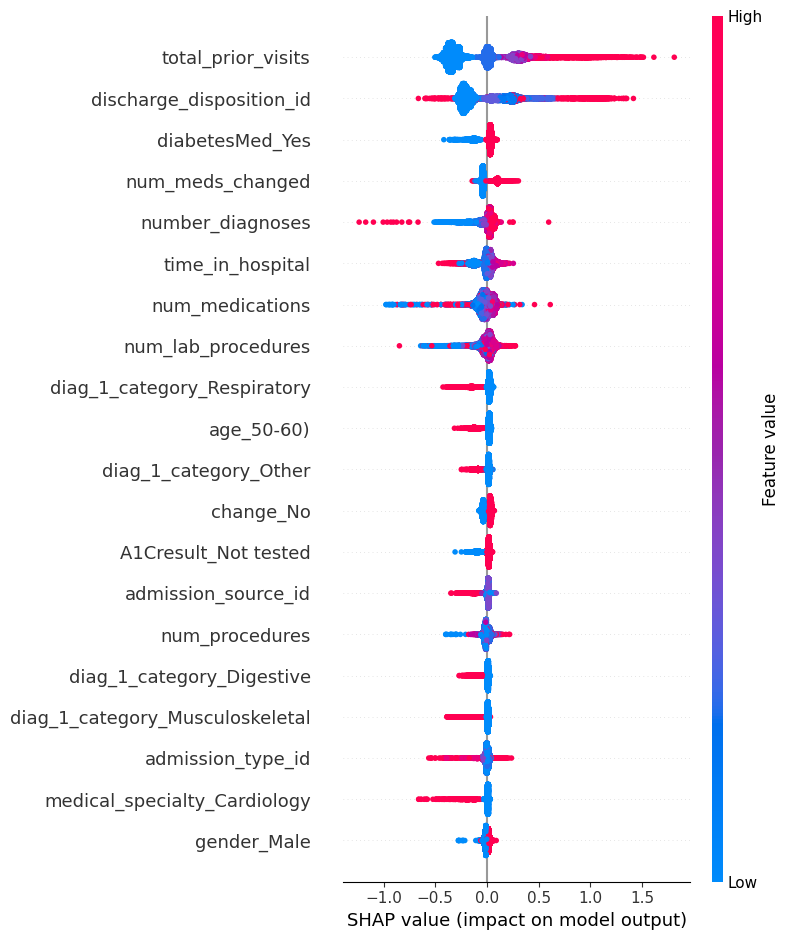

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

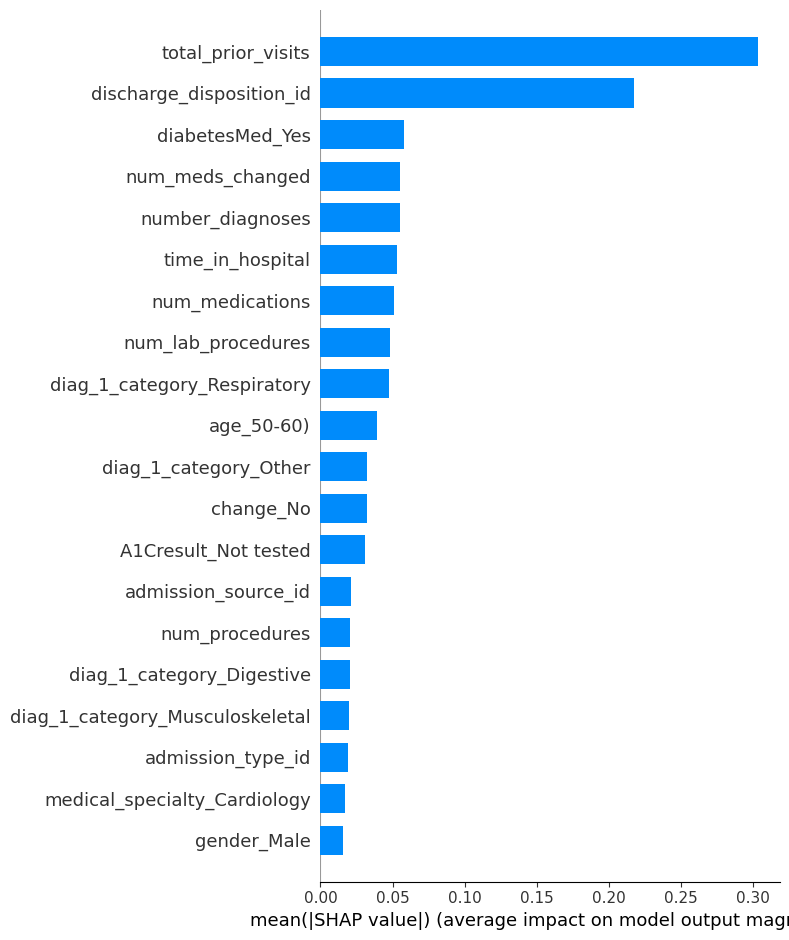

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Individual explanations (waterfall plots)
First: the first readmitted patient in the test set. Second: the readmitted patient the model was most confident about.

*Note:* XGBoost was trained with `scale_pos_weight`, which inflates raw probabilities, so predicted values are useful for ranking patients but should not be read as literal risk percentages.

Patient's actual outcome: readmitted = 1
Model's predicted probability of readmission: 0.369


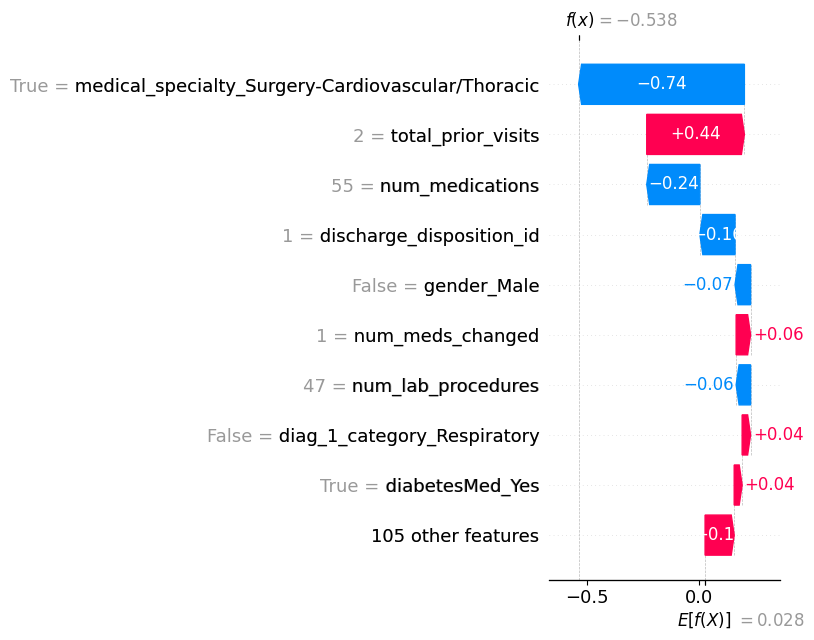

In [ ]:
# Pick one patient from the test set who was actually readmitted
patient_index = y_test[y_test == 1].index[0]
patient_position = X_test.index.get_loc(patient_index)

print(f"Patient's actual outcome: readmitted = {y_test.loc[patient_index]}")
print(f"Model's predicted probability of readmission: {y_proba_xgb[patient_position]:.3f}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_position],
        base_values=float(np.ravel(explainer.expected_value)[0]),
        data=X_test.iloc[patient_position],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

Patient's actual outcome: readmitted = 1
Model's predicted probability of readmission: 0.903


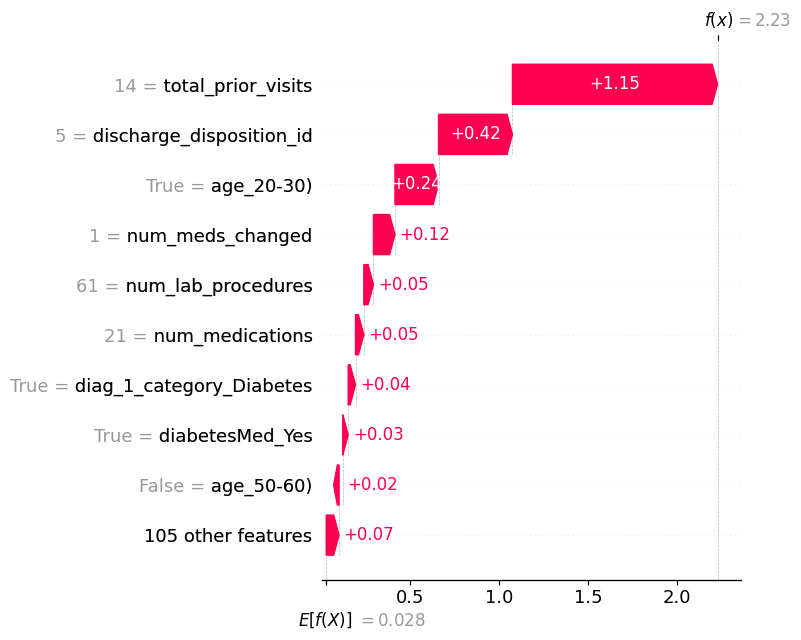

In [ ]:
# Among patients who were actually readmitted, find the one the model was MOST confident about
readmitted_positions = np.where(y_test.values == 1)[0]
best_position = readmitted_positions[np.argmax(y_proba_xgb[readmitted_positions])]

print(f"Patient's actual outcome: readmitted = {y_test.iloc[best_position]}")
print(f"Model's predicted probability of readmission: {y_proba_xgb[best_position]:.3f}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[best_position],
        base_values=float(np.ravel(explainer.expected_value)[0]),
        data=X_test.iloc[best_position],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall_true_positive.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Final results table (tuned models)
Precision, recall and F1 use a decision threshold chosen on the **training** data only (3-fold cross-validated predictions), so the test set stays unseen. Brier scores are shown against the score of a model that always predicts the average readmission rate.

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (roc_auc_score, brier_score_loss, precision_score,
                             recall_score, f1_score, precision_recall_curve)

# The decision threshold is chosen on the TRAINING data only (3-fold cross-validated
# predictions), so the test set stays completely unseen when we pick it.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

models = {
    'Logistic Regression': (lr_tuned, X_train_scaled, X_test_scaled),
    'Random Forest':       (rf_tuned, X_train, X_test),
    'XGBoost':             (xgb_tuned, X_train, X_test),
}

rows = []
for name, (model, X_tr, X_te) in models.items():
    p_cv = cross_val_predict(model, X_tr, y_train, cv=cv, method='predict_proba')[:, 1]
    prec, rec, thr = precision_recall_curve(y_train, p_cv)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-10)
    threshold = thr[f1_curve[:-1].argmax()]

    p_test = model.predict_proba(X_te)[:, 1]
    pred = (p_test >= threshold).astype(int)
    rows.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, p_test),
        'Threshold': threshold,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'Brier': brier_score_loss(y_test, p_test),
    })

results = pd.DataFrame(rows).set_index('Model').round(4)
print(results)

base_rate = y_test.mean()
print(f"\nBrier score of a model that always predicts the average rate ({base_rate:.3f}): {base_rate*(1-base_rate):.4f}")


                     AUC-ROC  Threshold  Precision  Recall      F1   Brier
Model                                                                     
Logistic Regression   0.6409     0.5214     0.1764  0.4505  0.2535  0.2342
Random Forest         0.6573     0.3323     0.1789  0.5234  0.2666  0.1318
XGBoost               0.6646     0.5418     0.1970  0.4947  0.2818  0.2242

Brier score of a model that always predicts the average rate (0.114): 0.1009


## 10. Sensitivity check: patient-grouped splits
The same patient can appear in several encounters. This check repeats the evaluation with splits that keep every patient entirely in training or entirely in testing, and prints the ROC curve points used for the paper's ROC figure.

In [ ]:
import re
import numpy as np
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# Part A: how many test encounters belong to patients who also appear in the training data?
patients = df.loc[X.index, 'patient_nbr']
train_patients = set(patients.loc[X_train.index])
share = patients.loc[X_test.index].isin(train_patients).mean()
print(f"Unique patients: {patients.nunique()} across {len(patients)} encounters")
print(f"Test encounters from patients also in the training data: {share*100:.1f}%")

# Part B: repeat the evaluation with patient-grouped splits (no patient in both train and test)
X_all = X.copy()
X_all.columns = [re.sub(r'[\[\]<]', '', c) for c in X_all.columns]
print("\nAUC-ROC with patient-grouped splits:")
for seed in [1, 2, 3]:
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                  .split(X_all, y, groups=patients.values))
    Xtr, Xte, ytr, yte = X_all.iloc[tr], X_all.iloc[te], y.iloc[tr], y.iloc[te]
    sc = StandardScaler().fit(Xtr)
    lr_m = clone(lr_tuned).fit(sc.transform(Xtr), ytr)
    rf_m = clone(rf_tuned).fit(Xtr, ytr)
    xg_m = clone(xgb_tuned).fit(Xtr, ytr)
    print(f"  seed {seed}: LR {roc_auc_score(yte, lr_m.predict_proba(sc.transform(Xte))[:,1]):.4f} | "
          f"RF {roc_auc_score(yte, rf_m.predict_proba(Xte)[:,1]):.4f} | "
          f"XGB {roc_auc_score(yte, xg_m.predict_proba(Xte)[:,1]):.4f}")

# Part C: ROC curve points (so the curves can be drawn in the paper)
grid = np.linspace(0, 1, 51)
print("\nROC curve points (true-positive rate at 51 evenly spaced false-positive rates):")
for name, p in [('LR', y_proba_lr), ('RF', y_proba_rf), ('XGB', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    print(name, [round(float(v), 4) for v in np.interp(grid, fpr, tpr)])


Unique patients: 69982 across 99323 encounters
Test encounters from patients also in the training data: 41.4%

AUC-ROC with patient-grouped splits:
  seed 1: LR 0.6332 | RF 0.6478 | XGB 0.6537
  seed 2: LR 0.6524 | RF 0.6630 | XGB 0.6727
  seed 3: LR 0.6456 | RF 0.6597 | XGB 0.6656

ROC curve points (true-positive rate at 51 evenly spaced false-positive rates):
LR [0.0, 0.0654, 0.1132, 0.1565, 0.1879, 0.2202, 0.2502, 0.2763, 0.3046, 0.3378, 0.3634, 0.3935, 0.4134, 0.4403, 0.4629, 0.4894, 0.5088, 0.5345, 0.5561, 0.5747, 0.6004, 0.6185, 0.6446, 0.6587, 0.6786, 0.6919, 0.7091, 0.7308, 0.7471, 0.7622, 0.7772, 0.7931, 0.8112, 0.8307, 0.8431, 0.8554, 0.8674, 0.8806, 0.8939, 0.9023, 0.9164, 0.9266, 0.9385, 0.9483, 0.9584, 0.9651, 0.977, 0.9823, 0.9885, 0.9956, 1.0]
RF [0.0, 0.0721, 0.1229, 0.1618, 0.1985, 0.2356, 0.2683, 0.3011, 0.3347, 0.3643, 0.3952, 0.4169, 0.4421, 0.466, 0.4876, 0.5159, 0.5371, 0.561, 0.5827, 0.6092, 0.6295, 0.6481, 0.6755, 0.6905, 0.7038, 0.7277, 0.7436, 0.7591, 0.775, 0

## 11. Confusion counts, average precision and DeLong check
Patient counts at the training-derived thresholds, average precision, and a check that the DeLong standard error matches a paired bootstrap.

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score)

# Part A: confusion counts and precision-recall summary at the same training-derived thresholds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
models = {
    'Logistic Regression': (lr_tuned, X_train_scaled, X_test_scaled),
    'Random Forest':       (rf_tuned, X_train, X_test),
    'XGBoost':             (xgb_tuned, X_train, X_test),
}
for name, (model, X_tr, X_te) in models.items():
    p_cv = cross_val_predict(model, X_tr, y_train, cv=cv, method='predict_proba')[:, 1]
    prec, rec, thr = precision_recall_curve(y_train, p_cv)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-10)
    t = thr[f1_curve[:-1].argmax()]
    p_test = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, (p_test >= t).astype(int)).ravel()
    print(f"{name}: TP={tp}, FP={fp}, FN={fn}, TN={tn} | flagged {100*(tp+fp)/len(y_test):.1f}% of patients | "
          f"average precision {average_precision_score(y_test, p_test):.4f}")
print(f"Average precision of a model with no skill (= prevalence): {y_test.mean():.4f}")

# Part B: check our DeLong function against a paired bootstrap of the same AUC difference
aucs, z, p = delong_roc_test(y_test, y_proba_xgb, y_proba_lr)
se_delong = abs(aucs[0] - aucs[1]) / z
rng = np.random.RandomState(1)
y_arr = np.array(y_test)
diffs = []
for _ in range(1000):
    idx = rng.randint(0, len(y_arr), len(y_arr))
    if len(np.unique(y_arr[idx])) < 2:
        continue
    diffs.append(roc_auc_score(y_arr[idx], y_proba_xgb[idx]) - roc_auc_score(y_arr[idx], y_proba_lr[idx]))
print(f"\nXGBoost minus Logistic Regression AUC, standard error: "
      f"DeLong = {se_delong:.5f} | 1,000 paired bootstraps = {np.std(diffs, ddof=1):.5f}")


Logistic Regression: TP=1019, FP=4757, FN=1243, TN=12846 | flagged 29.1% of patients | average precision 0.1860
Random Forest: TP=1184, FP=5436, FN=1078, TN=12167 | flagged 33.3% of patients | average precision 0.2027
XGBoost: TP=1119, FP=4562, FN=1143, TN=13041 | flagged 28.6% of patients | average precision 0.2126
Average precision of a model with no skill (= prevalence): 0.1139

XGBoost minus Logistic Regression AUC, standard error: DeLong = 0.00366 | 1,000 paired bootstraps = 0.00365
